In [2]:
import os
print("Current Working Directory:")
print(os.getcwd())

import os

os.chdir(r"C:\Users\vinay kumar\OneDrive\Documents\vinay\ML_Project\ai-workplace-productivity-analysis")

print(os.getcwd())
print(os.listdir("data"))



Current Working Directory:
c:\Users\vinay kumar\OneDrive\Documents\vinay\ML_Project\ai-workplace-productivity-analysis\classification
C:\Users\vinay kumar\OneDrive\Documents\vinay\ML_Project\ai-workplace-productivity-analysis
['train.csv']


--- Decision Tree Model Evaluation ---
Accuracy:  0.1750
Precision: 0.1814
Recall:    0.1750
F1 Score:  0.1764

Classification Report:
               precision    recall  f1-score   support

           1       0.20      0.21      0.20       124
           2       0.12      0.17      0.14       101
           3       0.25      0.19      0.22       129
           4       0.17      0.13      0.15       123
           5       0.16      0.17      0.17       123

    accuracy                           0.17       600
   macro avg       0.18      0.17      0.17       600
weighted avg       0.18      0.17      0.18       600



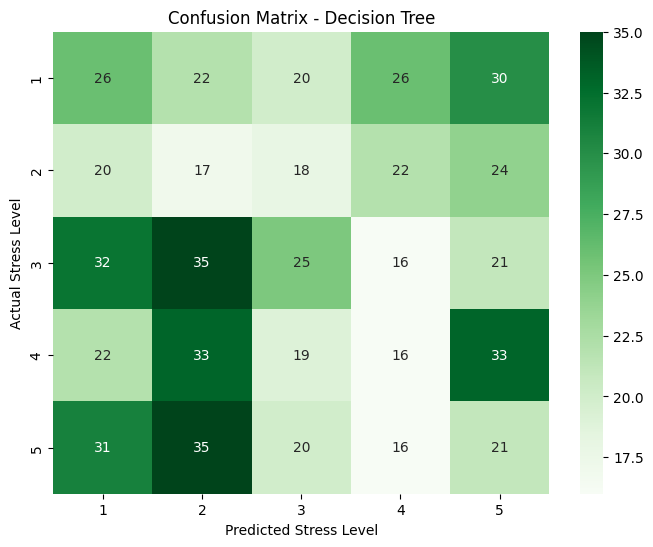

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report)


file_path = "train.csv" 
df = pd.read_csv("data/train.csv")


X = df.drop(columns=['Employee_Id', 'Stress_Level'])
y = df['Stress_Level']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)


categorical_cols = X_train.select_dtypes(include=['object', 'string']).columns.tolist()
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# ==========================================
# 5. Preprocessing Pipeline
# ==========================================
# Decision Trees do not require numerical scaling, so we "passthrough" numericals.
# We apply OneHotEncoder to categorical columns to avoid the 0,1,2 order problem.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ])

# ==========================================
# 6. Create and Train the Model Pipeline
# ==========================================
# We wrap the preprocessor and the model together.
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42, max_depth=10, min_samples_split=10))
])


pipeline.fit(X_train, y_train)


y_pred = pipeline.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
cm = confusion_matrix(y_test, y_pred)

print(f"--- Decision Tree Model Evaluation ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted Stress Level')
plt.ylabel('Actual Stress Level')
plt.title('Confusion Matrix - Decision Tree')
plt.show()

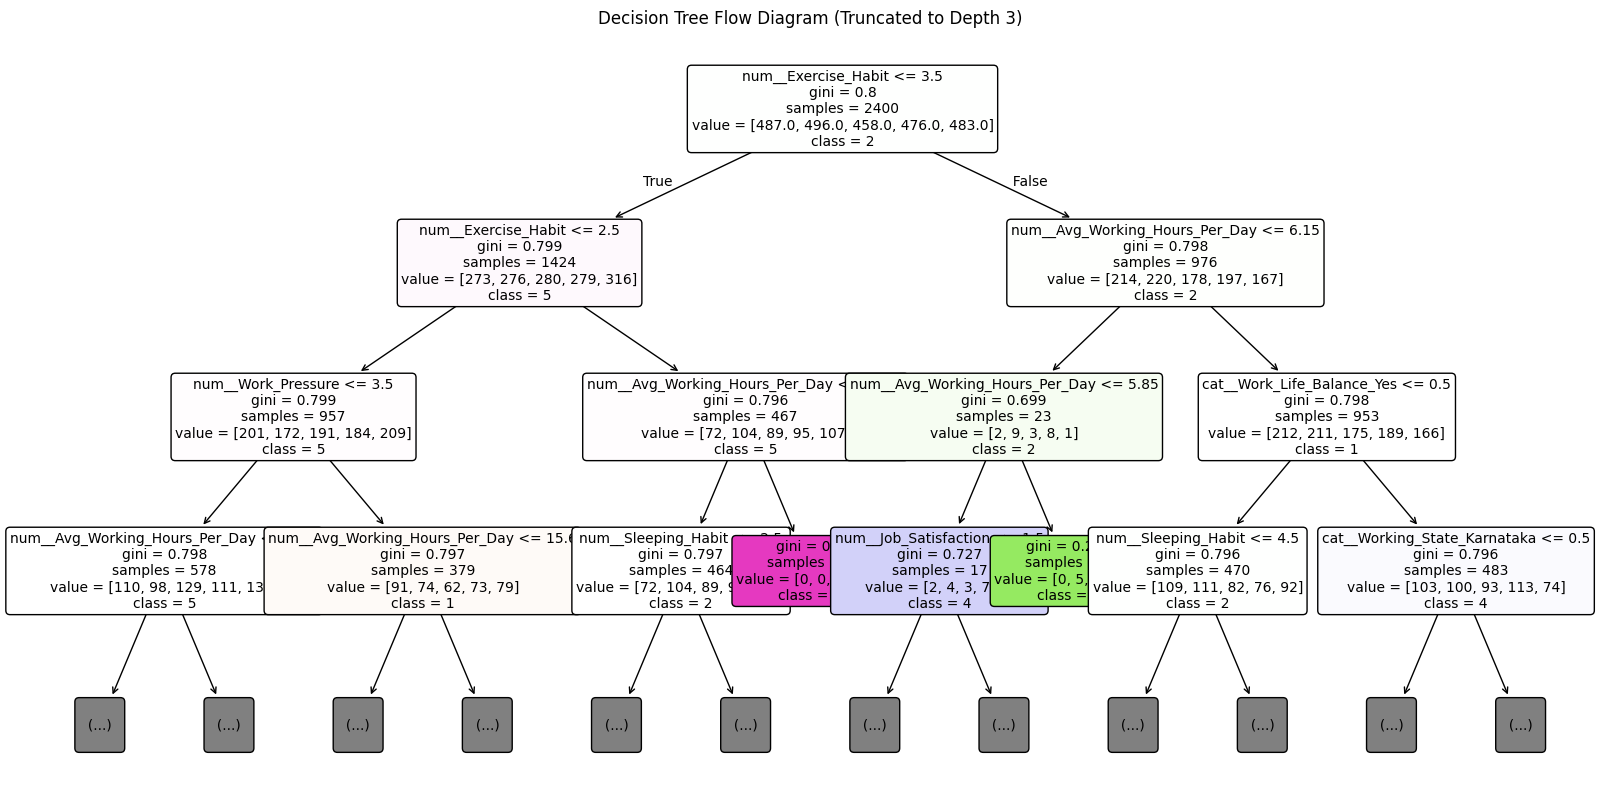

In [10]:
from sklearn.tree import plot_tree

# 1. Extract the trained Decision Tree from the pipeline
trained_tree = pipeline.named_steps['classifier']

# 2. Extract the feature names from the preprocessor
# This is necessary because OneHotEncoder changes the column names (e.g., 'Work_From_Home')
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

# 3. Class names (Target variables: 1, 2, 3, 4, 5)
class_names = [str(c) for c in np.unique(y)]

# 4. Plot the tree
plt.figure(figsize=(20, 10)) # Make the figure large enough to read

# We limit the max_depth to 3 for the diagram so it remains readable.
# If you want to see the whole tree, remove the max_depth parameter (but it will be very cluttered).
plot_tree(trained_tree, 
          feature_names=feature_names, 
          class_names=class_names, 
          filled=True, 
          rounded=True, 
          fontsize=10,
          max_depth=3) 

plt.title("Decision Tree Flow Diagram (Truncated to Depth 3)")
plt.show()